In [208]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler #mean=0 and sigma=1
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

##Loading Dataset and Data exploration

In [209]:
df=pd.read_csv('/content/StrokeـPredictio_Data.csv')


In [210]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [212]:
df.shape

(5110, 12)

In [213]:
df.size

61320

In [214]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## Cleaning and Preprocessing Dataset

In [215]:
df.drop('id',axis=1,inplace=True)

In [216]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [217]:
print(df.isnull().sum())

# Handle missing BMI values by imputing with the mean
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


/tmp/ipykernel_3091/1109556055.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].mean(), inplace=True)


##Exploratory Data Analysis - EDA

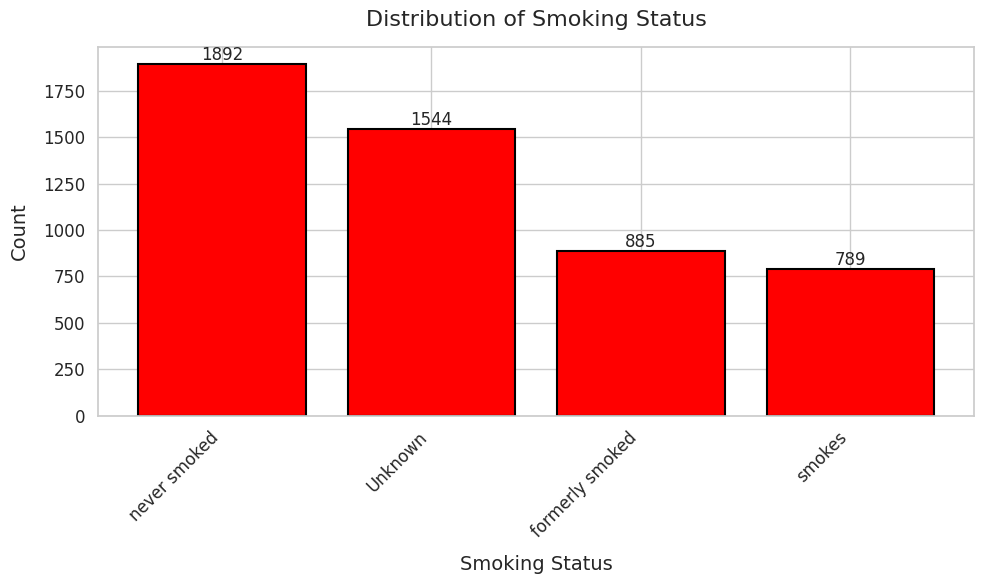

In [218]:
smoking_status_counts = df["smoking_status"].value_counts()

plt.figure(figsize=(10, 6))
bars = plt.bar(smoking_status_counts.index, smoking_status_counts.values, color='red', edgecolor='black', linewidth=1.5)
plt.xlabel("Smoking Status", fontsize=14, labelpad=10)
plt.ylabel("Count", fontsize=14, labelpad=10)
plt.title("Distribution of Smoking Status", fontsize=16, pad=15)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.05, int(yval), ha='center', va='bottom', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


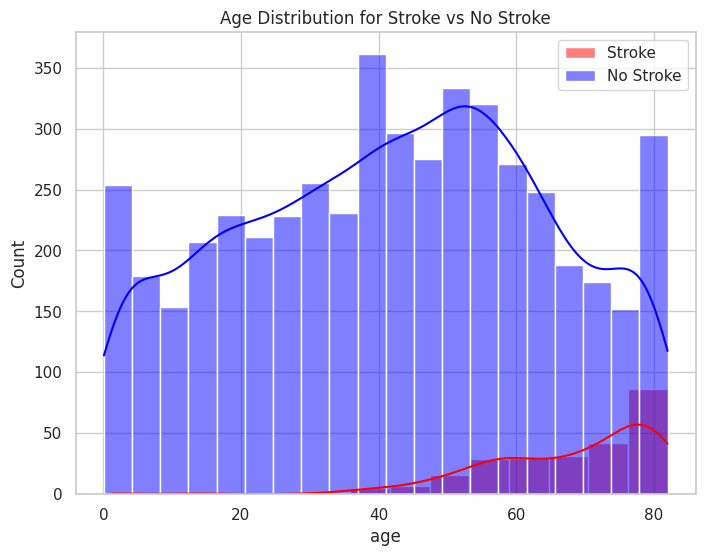

In [219]:
sns.set(style="whitegrid")
# Distribution of Age
plt.figure(figsize=(8,6))
sns.histplot(df[df['stroke'] == 1]['age'], kde=True, color='red', label='Stroke')
sns.histplot(df[df['stroke'] == 0]['age'], kde=True, color='blue', label='No Stroke')
plt.title('Age Distribution for Stroke vs No Stroke')
plt.legend()
plt.show()

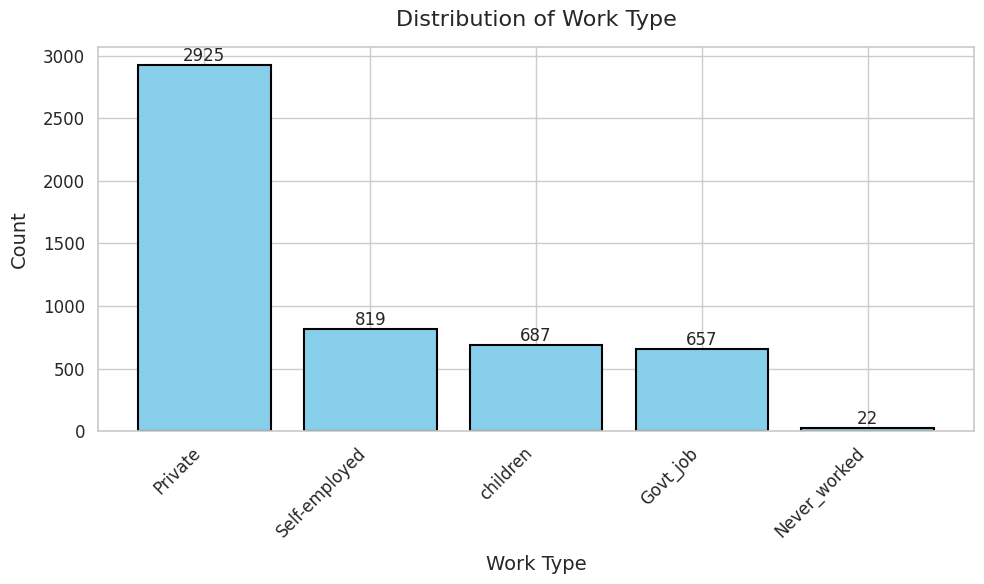

In [220]:
work_type_counts = df["work_type"].value_counts()

plt.figure(figsize=(10, 6))
bars = plt.bar(work_type_counts.index, work_type_counts.values, color='skyblue', edgecolor='black', linewidth=1.5)
plt.xlabel("Work Type", fontsize=14, labelpad=10)
plt.ylabel("Count", fontsize=14, labelpad=10)
plt.title("Distribution of Work Type", fontsize=16, pad=15)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.05, int(yval), ha='center', va='bottom', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

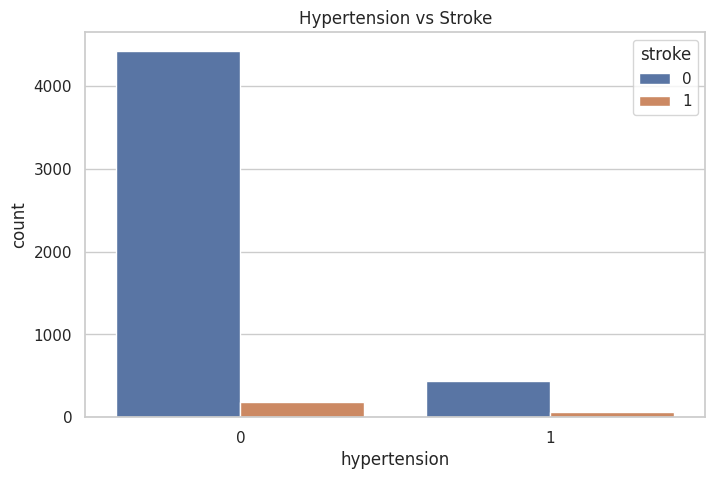

In [221]:
# Hypertension vs Stroke
plt.figure(figsize=(8,5))
sns.countplot(x='hypertension', hue='stroke', data=df)
plt.title('Hypertension vs Stroke')
plt.show()

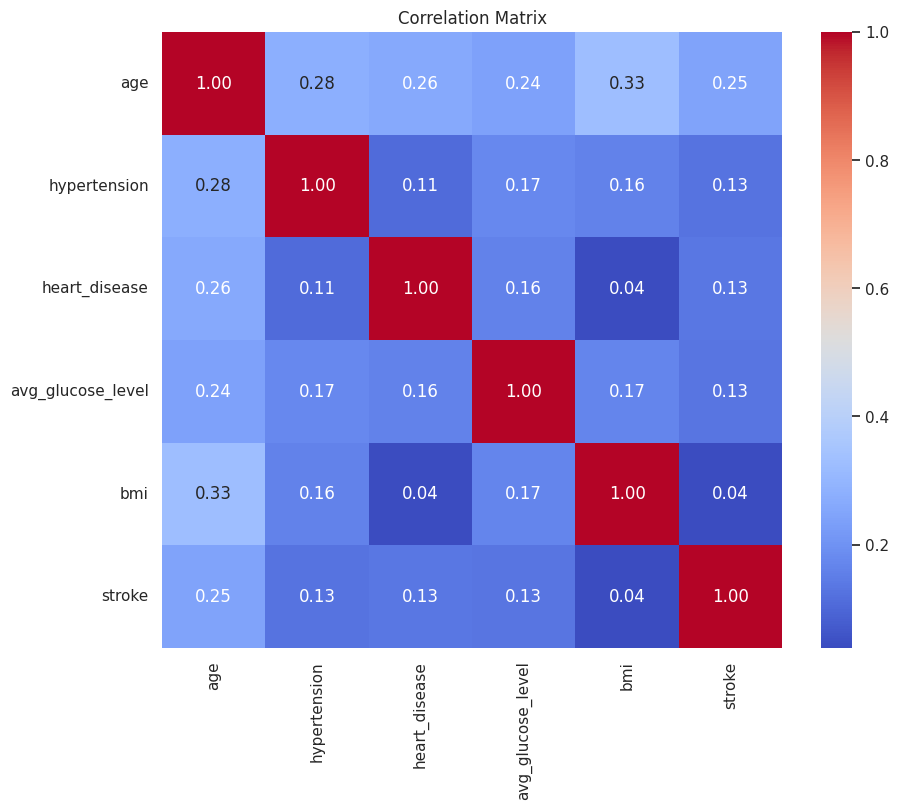

In [222]:
plt.figure(figsize=(10, 8))
numerical_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### Encoding Categorical Features



In [223]:
# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'], drop_first=True)



display(df_encoded.head())

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.600000,1,True,False,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.893237,1,False,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.500000,1,True,False,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.400000,1,False,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.000000,1,False,False,True,False,False,True,False,False,False,True,False


In [224]:
#mean =0  sd=1
scaler = StandardScaler()
df[['age', 'avg_glucose_level', 'bmi']] = scaler.fit_transform(df[['age', 'avg_glucose_level', 'bmi']])

In [225]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,1.051434,0,1,Yes,Private,Urban,2.706375,1.001234e+00,formerly smoked,1
1,Female,0.786070,0,0,Yes,Self-employed,Rural,2.121559,4.615554e-16,never smoked,1
2,Male,1.626390,0,1,Yes,Private,Rural,-0.005028,4.685773e-01,never smoked,1
3,Female,0.255342,0,0,Yes,Private,Urban,1.437358,7.154182e-01,smokes,1
4,Female,1.582163,1,0,Yes,Self-employed,Rural,1.501184,-6.357112e-01,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,1.626390,1,0,Yes,Private,Urban,-0.494658,4.615554e-16,never smoked,0
5106,Female,1.670617,0,0,Yes,Self-employed,Urban,0.420775,1.442949e+00,never smoked,0
5107,Female,-0.363842,0,0,Yes,Self-employed,Rural,-0.511443,2.217363e-01,never smoked,0
5108,Male,0.343796,0,0,Yes,Private,Rural,1.328257,-4.278451e-01,formerly smoked,0


## Splitting Data into Training and Testing Sets



In [226]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (4088, 16)
X_test shape: (1022, 16)
y_train shape: (4088,)
y_test shape: (1022,)


In [227]:
from imblearn.combine import SMOTETomek

x_resampled, y_resampled = SMOTETomek(random_state=42).fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(x_resampled, y_resampled, test_size=0.2, random_state=29)


## Logistic Regression



Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.73      0.76       964
           1       0.75      0.82      0.78       960

    accuracy                           0.77      1924
   macro avg       0.78      0.77      0.77      1924
weighted avg       0.78      0.77      0.77      1924



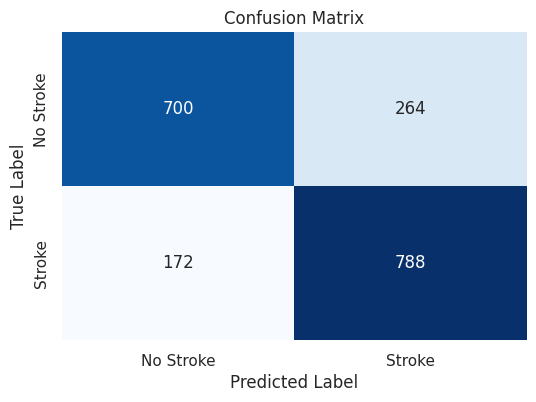

In [228]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()